# 📈 Prédiction de Séries Temporelles — NASDAQ-100
## Projet de fin de module — Deep Learning | EMSI Casablanca 2025–2026

**Sujet 7 : Prédiction de séries temporelles**  
**Dataset :** NASDAQ-100 (^NDX) — données journalières 2022–2024  
**Architecture :** LSTM / GRU avec fenêtres glissantes  
**Framework :** PyTorch

---
> Ce notebook constitue l'implémentation complète du projet, incluant :
> - Téléchargement et exploration des données
> - Préparation (normalisation, fenêtres glissantes)
> - Modèles LSTM et GRU sous PyTorch
> - Entraînement avec MSELoss + Adam
> - Évaluation : MAE, RMSE
> - Visualisations et analyse critique


In [1]:
import sys
!{sys.executable} -m pip install yfinance torch scikit-learn

## 1. 📦 Imports et configuration

In [2]:
# ── Installations (à exécuter une fois) ──────────────────────────────────────
# !pip install yfinance torch pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Utilitaires
import time
import math

# ── Configuration globale ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device (GPU si disponible, sinon CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device utilisé : {DEVICE}")
print(f"✅ PyTorch version : {torch.__version__}")


✅ Device utilisé : cpu
✅ PyTorch version : 2.10.0+cpu


## 2. 📚 Fondements théoriques

### 2.1 Modèles de langage et séries temporelles
Un modèle de langage prédit la prochaine valeur d'une séquence à partir du passé.  
Pour une série temporelle $(x_1, x_2, ..., x_T)$, on factorise la probabilité jointe :

$$P(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, ..., x_{t-1})$$

### 2.2 Le problème du vanishing gradient dans les RNN simples
Les RNN classiques souffrent du **vanishing gradient** : lors de la rétropropagation à travers le temps (BPTT), les gradients sont multipliés par les poids à chaque pas de temps, ce qui les fait tendre vers 0 pour les longues séquences.

### 2.3 La cellule LSTM
Le **Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) résout ce problème grâce à trois portes :

| Porte | Formule | Rôle |
|-------|---------|------|
| **Oubli** | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | Ce qu'on oublie de la mémoire |
| **Entrée** | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | Ce qu'on mémorise de l'entrée |
| **Sortie** | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | Ce qu'on expose en sortie |

La cellule mémoire $c_t$ est mise à jour :
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

### 2.4 La cellule GRU
Le **Gated Recurrent Unit** (Cho et al., 2014) simplifie le LSTM avec seulement deux portes :
- **Porte de réinitialisation** $r_t$ : contrôle l'influence du passé
- **Porte de mise à jour** $z_t$ : contrôle la fusion passé/présent

Le GRU est plus rapide à entraîner et souvent aussi performant que le LSTM.

### 2.5 Fenêtre glissante
Pour construire les séquences d'entraînement, on utilise une fenêtre glissante de taille $W$ :

```
Données : [x1, x2, x3, ..., x100]
Fenêtre W=24 :
  X = [x1,...,x24]  →  y = x25
  X = [x2,...,x25]  →  y = x26
  ...
```


## 3. 📥 Téléchargement et exploration des données

In [3]:
print("📡 Téléchargement du NASDAQ-100 via QQQ 2022–2024...")

df_raw = yf.download("QQQ", start="2022-01-01", end="2024-12-31", interval="1d")

# Nettoyage
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw = df_raw[["Open", "High", "Low", "Close", "Volume"]]
df_raw.index = pd.to_datetime(df_raw.index).tz_localize(None)
df_raw.index.name = "Date"
df_raw = df_raw.dropna()

print(f"✅ Dataset chargé : {df_raw.shape[0]} jours, {df_raw.shape[1]} colonnes")
print(f"📅 Période : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"❌ Valeurs manquantes : {df_raw.isnull().sum().sum()}")
df_raw.head()

📡 Téléchargement du NASDAQ-100 via QQQ 2022–2024...


[*********************100%***********************]  1 of 1 completed

✅ Dataset chargé : 752 jours, 5 colonnes
📅 Période : 2022-01-03 → 2024-12-30
❌ Valeurs manquantes : 0


Price,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,388.624922,391.439435,386.511629,391.186218,40575900
2022-01-04,391.731585,391.770548,383.015419,386.112335,58027200
2022-01-05,384.427560,385.547540,373.997363,374.250580,75739800
2022-01-06,372.429463,377.230662,370.199280,373.987640,70814300
2022-01-07,373.997291,375.682106,368.163788,369.936218,72652300


In [4]:
# ── Statistiques descriptives ────────────────────────────────────────────────
print("=== Statistiques descriptives — colonne Close ===")
print(df_raw["Close"].describe().round(2))


=== Statistiques descriptives — colonne Close ===
count    752.00
mean     367.91
std       75.19
min      254.94
25%      300.90
50%      357.34
75%      433.46
max      533.92
Name: Close, dtype: float64


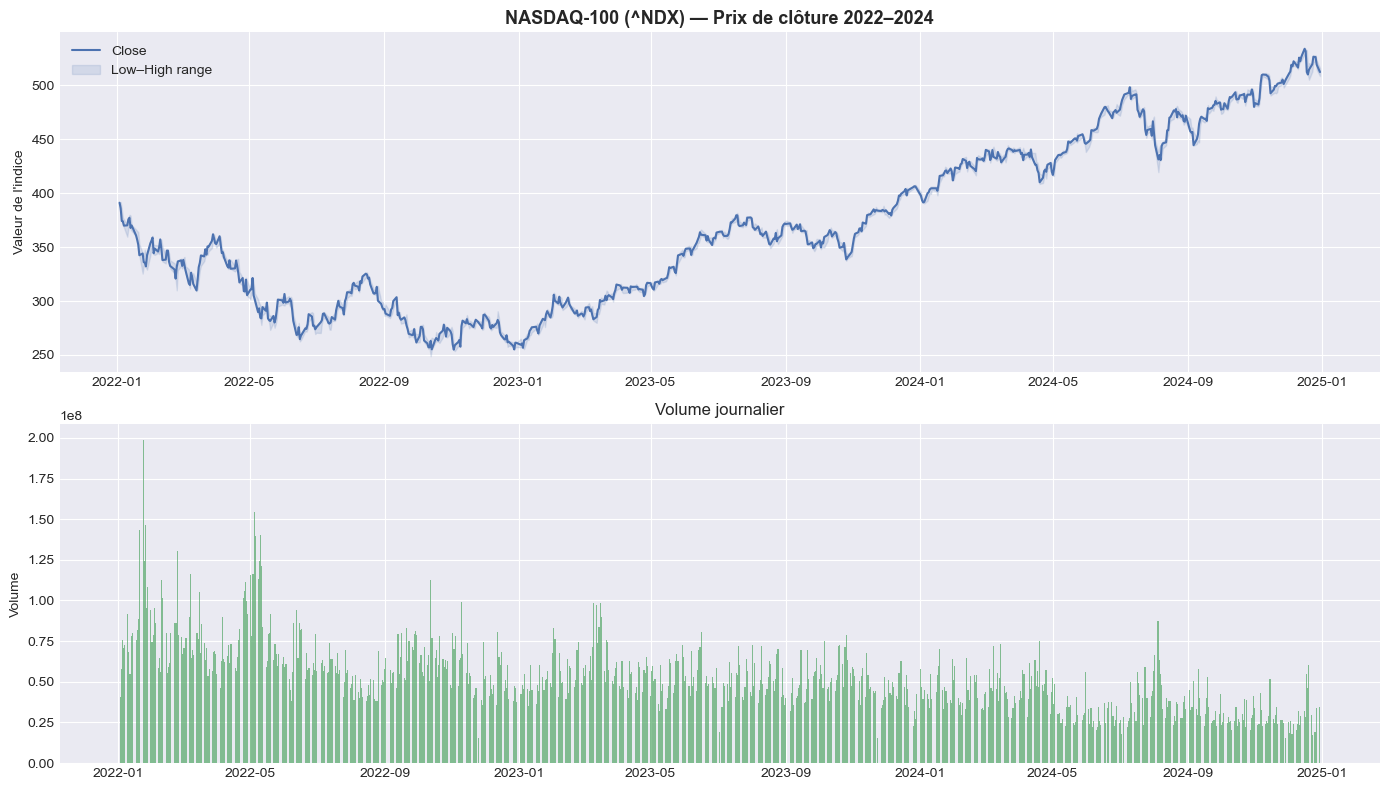

✅ Figure sauvegardée : nasdaq100_serie_brute.png


In [5]:
# ── Visualisation de la série brute ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Prix de clôture
axes[0].plot(df_raw.index, df_raw["Close"], color='#4C72B0', linewidth=1.5, label='Close')
axes[0].fill_between(df_raw.index, df_raw["Low"], df_raw["High"], alpha=0.15, color='#4C72B0', label='Low–High range')
axes[0].set_title("NASDAQ-100 (^NDX) — Prix de clôture 2022–2024", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Valeur de l'indice")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Volume
axes[1].bar(df_raw.index, df_raw["Volume"], color='#55A868', alpha=0.7, width=1)
axes[1].set_title("Volume journalier", fontsize=12)
axes[1].set_ylabel("Volume")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('nasdaq100_serie_brute.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : nasdaq100_serie_brute.png")


## 4. 🔧 Préparation des données

In [6]:
# ── Paramètres globaux ───────────────────────────────────────────────────────
SEQ_LEN    = 24     # Taille de la fenêtre (24 jours → prédit le 25e)
BATCH_SIZE = 32     # Taille des mini-lots
TRAIN_RATIO = 0.70  # 70% entraînement
VAL_RATIO   = 0.15  # 15% validation
# 15% test (implicite)

# ── Sélection de la variable cible ───────────────────────────────────────────
# On utilise uniquement la colonne "Close" (série univariée)
close_prices = df_raw["Close"].values.reshape(-1, 1)
print(f"Série Close : {close_prices.shape[0]} valeurs")
print(f"Min : {close_prices.min():.2f}  |  Max : {close_prices.max():.2f}")


Série Close : 752 valeurs
Min : 254.94  |  Max : 533.92


In [7]:
# ── Normalisation MinMaxScaler ────────────────────────────────────────────────
# IMPORTANT : le scaler est fitté UNIQUEMENT sur le train pour éviter le data leakage

n = len(close_prices)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

scaler = MinMaxScaler(feature_range=(0, 1))
# Fit uniquement sur le train
scaler.fit(close_prices[:n_train])

# Transformation de toute la série (avec le scaler fitté sur le train)
scaled = scaler.transform(close_prices)

print(f"Total   : {n} jours")
print(f"Train   : {n_train} jours  ({TRAIN_RATIO*100:.0f}%)")
print(f"Val     : {n_val} jours  ({VAL_RATIO*100:.0f}%)")
print(f"Test    : {n_test} jours  ({(1-TRAIN_RATIO-VAL_RATIO)*100:.0f}%)")
print(f"Après normalisation — Min : {scaled.min():.4f}  Max : {scaled.max():.4f}")


Total   : 752 jours
Train   : 526 jours  (70%)
Val     : 112 jours  (15%)
Test    : 114 jours  (15%)
Après normalisation — Min : 0.0000  Max : 1.6523


In [8]:
# ── Création des fenêtres glissantes ─────────────────────────────────────────
def create_sequences(data, seq_len):
    """
    Transforme une série 1D en paires (X, y) avec fenêtre glissante.
    X : séquence de seq_len valeurs → shape [N, seq_len, 1]
    y : valeur suivante            → shape [N, 1]
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

# Séparation train / val / test AVANT la création des séquences
train_data = scaled[:n_train + SEQ_LEN]   # on garde un chevauchement pour les seq
val_data   = scaled[n_train : n_train + n_val + SEQ_LEN]
test_data  = scaled[n_train + n_val :]

X_train, y_train = create_sequences(train_data, SEQ_LEN)
X_val,   y_val   = create_sequences(val_data,   SEQ_LEN)
X_test,  y_test  = create_sequences(test_data,  SEQ_LEN)

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"\nFormat attendu par PyTorch : [batch, seq_len={SEQ_LEN}, features=1] ✅")


X_train : (526, 24, 1)  y_train : (526, 1)
X_val   : (112, 24, 1)    y_val   : (112, 1)
X_test  : (90, 24, 1)   y_test  : (90, 1)

Format attendu par PyTorch : [batch, seq_len=24, features=1] ✅


In [9]:
# ── Dataset et DataLoader PyTorch ────────────────────────────────────────────
class TimeSeriesDataset(Dataset):
    """Dataset PyTorch pour séries temporelles."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val,   y_val)
test_dataset  = TimeSeriesDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders créés")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

# Vérification d'un batch
xb, yb = next(iter(train_loader))
print(f"\nBatch X : {xb.shape}  →  [batch={BATCH_SIZE}, seq_len={SEQ_LEN}, features=1]")
print(f"Batch y : {yb.shape}  →  [batch={BATCH_SIZE}, 1]")


✅ DataLoaders créés
   Train batches : 17
   Val batches   : 4
   Test batches  : 3

Batch X : torch.Size([32, 24, 1])  →  [batch=32, seq_len=24, features=1]
Batch y : torch.Size([32, 1])  →  [batch=32, 1]


## 5. 🤖 Définition des modèles PyTorch

In [10]:
# ── Modèle LSTM ──────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    LSTM pour prédiction de séries temporelles.

    Architecture :
        Entrée [batch, seq_len, input_size]
            → nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            → Dernier état caché h_n [batch, hidden_size]
            → nn.Linear(hidden_size, output_size)
        Sortie [batch, 1]
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Couche LSTM principale (batch_first=True pour [batch, seq, features])
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,          # ← obligatoire selon le sujet
            dropout     = dropout if num_layers > 1 else 0.0
        )

        # Couche de sortie linéaire
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Initialisation des états cachés à zéro
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Passage dans le LSTM
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # On utilise le DERNIER état caché (représentation de toute la séquence)
        last_hidden = hn[-1]             # shape : [batch, hidden_size]
        last_hidden = self.dropout(last_hidden)

        # Projection vers la sortie scalaire
        prediction = self.fc(last_hidden) # shape : [batch, 1]
        return prediction


# ── Modèle GRU ───────────────────────────────────────────────────────────────
class GRUModel(nn.Module):
    """
    GRU pour prédiction de séries temporelles.
    Même architecture que le LSTM, mais avec nn.GRU (pas d'état de cellule c_t).
    Plus léger : 2/3 des paramètres d'un LSTM équivalent.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2,
                 output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.fc      = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, hn = self.gru(x, h0)          # GRU : pas de c0
        last_hidden = hn[-1]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)


# ── Instanciation et inspection ──────────────────────────────────────────────
INPUT_SIZE   = 1
HIDDEN_SIZE  = 64
NUM_LAYERS   = 2
DROPOUT      = 0.2

lstm_model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, 1, DROPOUT).to(DEVICE)
gru_model  = GRUModel( INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, 1, DROPOUT).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Architecture LSTM ===")
print(lstm_model)
print(f"\nParamètres entraînables LSTM : {count_params(lstm_model):,}")
print(f"Paramètres entraînables GRU  : {count_params(gru_model):,}")
print(f"\n✅ Ratio GRU/LSTM : {count_params(gru_model)/count_params(lstm_model):.2f} (GRU plus léger)")


=== Architecture LSTM ===
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

Paramètres entraînables LSTM : 50,497
Paramètres entraînables GRU  : 37,889

✅ Ratio GRU/LSTM : 0.75 (GRU plus léger)


In [11]:
# ── Inspection des paramètres nommés (named_parameters) ─────────────────────
print("=== Paramètres nommés du LSTM ===")
for name, param in lstm_model.named_parameters():
    print(f"  {name:45s} | shape : {str(param.shape):25s} | requires_grad : {param.requires_grad}")


=== Paramètres nommés du LSTM ===
  lstm.weight_ih_l0                             | shape : torch.Size([256, 1])      | requires_grad : True
  lstm.weight_hh_l0                             | shape : torch.Size([256, 64])     | requires_grad : True
  lstm.bias_ih_l0                               | shape : torch.Size([256])         | requires_grad : True
  lstm.bias_hh_l0                               | shape : torch.Size([256])         | requires_grad : True
  lstm.weight_ih_l1                             | shape : torch.Size([256, 64])     | requires_grad : True
  lstm.weight_hh_l1                             | shape : torch.Size([256, 64])     | requires_grad : True
  lstm.bias_ih_l1                               | shape : torch.Size([256])         | requires_grad : True
  lstm.bias_hh_l1                               | shape : torch.Size([256])         | requires_grad : True
  fc.weight                                     | shape : torch.Size([1, 64])       | requires_grad : True
  f

## 6. 🏋️ Entraînement des modèles

In [12]:
# ── Hyperparamètres d'entraînement ───────────────────────────────────────────
EPOCHS        = 60
LEARNING_RATE = 1e-3
CLIP_GRAD     = 1.0    # Gradient clipping pour stabiliser le BPTT

# ── Fonction d'entraînement générique ────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs, lr, clip_grad, model_name):
    """
    Entraîne un modèle LSTM ou GRU.
    - Critère : MSELoss (Mean Squared Error)
    - Optimiseur : Adam
    - Gradient clipping pour éviter les explosions de gradient (BPTT)
    Retourne l'historique des pertes train/val.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Scheduler : réduit le LR si la val_loss stagne
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=7, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state    = None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        # ── Phase entraînement ──────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()                     # Rétropropagation (BPTT)

            # Gradient clipping : évite l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Phase validation ────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                preds    = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        # Sauvegarde du meilleur modèle
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss : {train_loss:.6f} | Val Loss : {val_loss:.6f} | LR : {optimizer.param_groups[0]['lr']:.6f} | {elapsed:.1f}s")

    # Rechargement du meilleur état
    model.load_state_dict(best_state)
    torch.save(best_state, f'best_{model_name}.pt')
    print(f"\n✅ Meilleur modèle sauvegardé → best_{model_name}.pt (val_loss={best_val_loss:.6f})")
    return history


# ── Entraînement LSTM ─────────────────────────────────────────────────────────
print("=" * 60)
print("🔵 ENTRAÎNEMENT DU MODÈLE LSTM")
print("=" * 60)
history_lstm = train_model(lstm_model, train_loader, val_loader,
                           EPOCHS, LEARNING_RATE, CLIP_GRAD, "lstm")


🔵 ENTRAÎNEMENT DU MODÈLE LSTM
Epoch   1/60 | Train Loss : 0.190299 | Val Loss : 0.244235 | LR : 0.001000 | 0.6s
Epoch  10/60 | Train Loss : 0.005767 | Val Loss : 0.007589 | LR : 0.001000 | 3.1s
Epoch  20/60 | Train Loss : 0.004516 | Val Loss : 0.004468 | LR : 0.001000 | 5.7s
Epoch  30/60 | Train Loss : 0.004578 | Val Loss : 0.007006 | LR : 0.001000 | 7.9s
Epoch  40/60 | Train Loss : 0.003606 | Val Loss : 0.003765 | LR : 0.001000 | 10.5s
Epoch  50/60 | Train Loss : 0.004026 | Val Loss : 0.003281 | LR : 0.000500 | 13.0s
Epoch  60/60 | Train Loss : 0.003303 | Val Loss : 0.002851 | LR : 0.000500 | 15.2s

✅ Meilleur modèle sauvegardé → best_lstm.pt (val_loss=0.002851)


In [13]:
# ── Entraînement GRU ──────────────────────────────────────────────────────────
print("=" * 60)
print("🟢 ENTRAÎNEMENT DU MODÈLE GRU")
print("=" * 60)
history_gru = train_model(gru_model, train_loader, val_loader,
                          EPOCHS, LEARNING_RATE, CLIP_GRAD, "gru")


🟢 ENTRAÎNEMENT DU MODÈLE GRU
Epoch   1/60 | Train Loss : 0.121517 | Val Loss : 0.331298 | LR : 0.001000 | 0.9s
Epoch  10/60 | Train Loss : 0.004327 | Val Loss : 0.008967 | LR : 0.001000 | 6.0s
Epoch  20/60 | Train Loss : 0.003610 | Val Loss : 0.004129 | LR : 0.001000 | 11.9s
Epoch  30/60 | Train Loss : 0.003526 | Val Loss : 0.003079 | LR : 0.001000 | 17.6s
Epoch  40/60 | Train Loss : 0.003129 | Val Loss : 0.002466 | LR : 0.001000 | 23.2s
Epoch  50/60 | Train Loss : 0.002908 | Val Loss : 0.002961 | LR : 0.001000 | 28.8s
Epoch  60/60 | Train Loss : 0.002466 | Val Loss : 0.002339 | LR : 0.001000 | 34.8s

✅ Meilleur modèle sauvegardé → best_gru.pt (val_loss=0.002098)


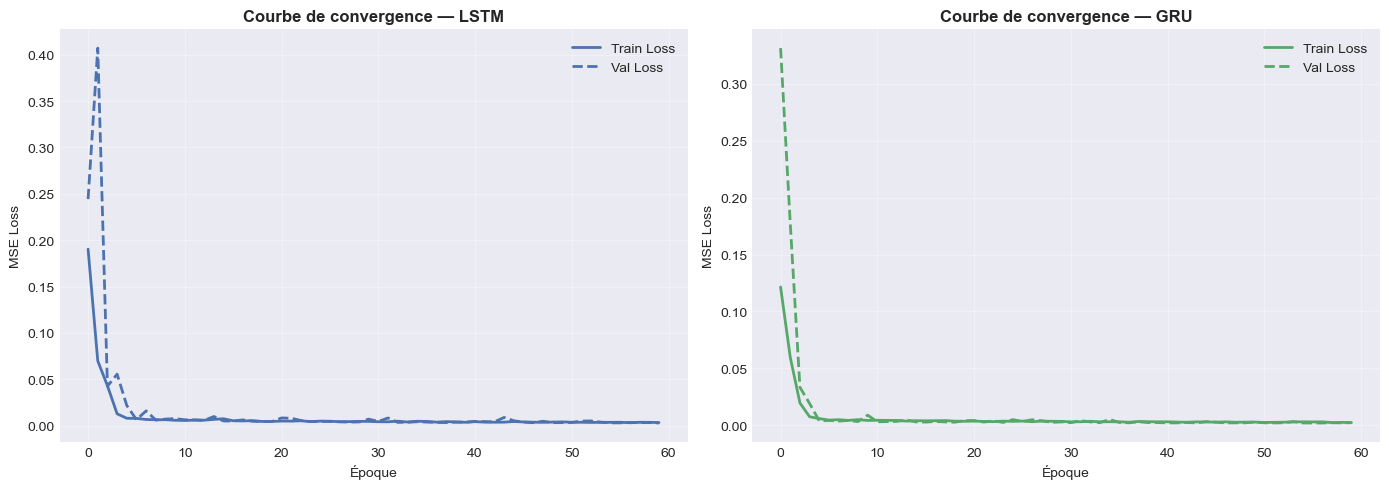

✅ Figure sauvegardée : courbes_convergence.png


In [14]:
# ── Courbes de convergence ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, name, color in zip(
    axes,
    [history_lstm, history_gru],
    ['LSTM', 'GRU'],
    ['#4C72B0', '#55A868']
):
    ax.plot(hist['train_loss'], label='Train Loss', color=color, linewidth=2)
    ax.plot(hist['val_loss'],   label='Val Loss',   color=color, linewidth=2, linestyle='--')
    ax.set_title(f"Courbe de convergence — {name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Époque")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('courbes_convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : courbes_convergence.png")


## 7. 📊 Évaluation et métriques

In [15]:
# ── Prédictions sur le set de test ───────────────────────────────────────────
def predict(model, loader):
    """Génère les prédictions sur un DataLoader, dénormalise et retourne les valeurs réelles."""
    model.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            out = model(X_batch).cpu().numpy()
            preds_list.append(out)
            true_list.append(y_batch.numpy())

    preds = np.concatenate(preds_list, axis=0)
    trues = np.concatenate(true_list,  axis=0)

    # Dénormalisation (inverse_transform)
    preds_inv = scaler.inverse_transform(preds)
    trues_inv = scaler.inverse_transform(trues)
    return preds_inv.flatten(), trues_inv.flatten()


preds_lstm, trues = predict(lstm_model, test_loader)
preds_gru,  _     = predict(gru_model,  test_loader)

# ── Calcul des métriques ──────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{'='*40}")
    print(f"  Modèle : {model_name}")
    print(f"  MAE   : {mae:.2f} points d'indice")
    print(f"  RMSE  : {rmse:.2f} points d'indice")
    print(f"  MAPE  : {mape:.2f} %")
    print(f"{'='*40}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

metrics_lstm = compute_metrics(trues, preds_lstm, "LSTM")
metrics_gru  = compute_metrics(trues, preds_gru,  "GRU")


  Modèle : LSTM
  MAE   : 7.54 points d'indice
  RMSE  : 9.18 points d'indice
  MAPE  : 1.52 %
  Modèle : GRU
  MAE   : 5.77 points d'indice
  RMSE  : 7.13 points d'indice
  MAPE  : 1.17 %


In [16]:
# ── Tableau comparatif LSTM vs GRU ───────────────────────────────────────────
results = pd.DataFrame({
    "Modèle"        : ["LSTM", "GRU"],
    "MAE"           : [round(metrics_lstm["MAE"],  2), round(metrics_gru["MAE"],  2)],
    "RMSE"          : [round(metrics_lstm["RMSE"], 2), round(metrics_gru["RMSE"], 2)],
    "MAPE (%)"      : [round(metrics_lstm["MAPE"], 2), round(metrics_gru["MAPE"], 2)],
    "Paramètres"    : [count_params(lstm_model), count_params(gru_model)],
}).set_index("Modèle")

print("\n=== Tableau comparatif LSTM vs GRU ===")
print(results.to_string())



=== Tableau comparatif LSTM vs GRU ===
         MAE  RMSE  MAPE (%)  Paramètres
Modèle                                  
LSTM    7.54  9.18      1.52       50497
GRU     5.77  7.13      1.17       37889


In [17]:
# Affichage prédit vs réel
comparaison = pd.DataFrame({
    "Réel ($)"         : trues[:10].round(2),
    "Prédit LSTM ($)"  : preds_lstm[:10].round(2),
    "Erreur LSTM ($)"  : (trues[:10] - preds_lstm[:10]).round(2),
    "Prédit GRU ($)"   : preds_gru[:10].round(2),
    "Erreur GRU ($)"   : (trues[:10] - preds_gru[:10]).round(2),
})
print(comparaison.to_string())

     Réel ($)  Prédit LSTM ($)  Erreur LSTM ($)  Prédit GRU ($)  Erreur GRU ($)
0  470.440002       475.459991            -5.02      473.640015           -3.20
1  475.540009       476.380005            -0.84      472.470001            3.07
2  470.920013       476.589996            -5.66      472.940002           -2.01
3  472.329987       475.559998            -3.23      472.190002            0.14
4  466.970001       474.260010            -7.29      472.040009           -5.07
5  466.290009       472.140015            -5.85      470.359985           -4.07
6  471.839996       469.820007             2.03      468.820007            3.03
7  457.519989       468.660004           -11.14      469.799988          -12.28
8  456.329987       466.019989            -9.69      466.119995           -9.79
9  456.760010       462.839996            -6.09      462.440002           -5.68


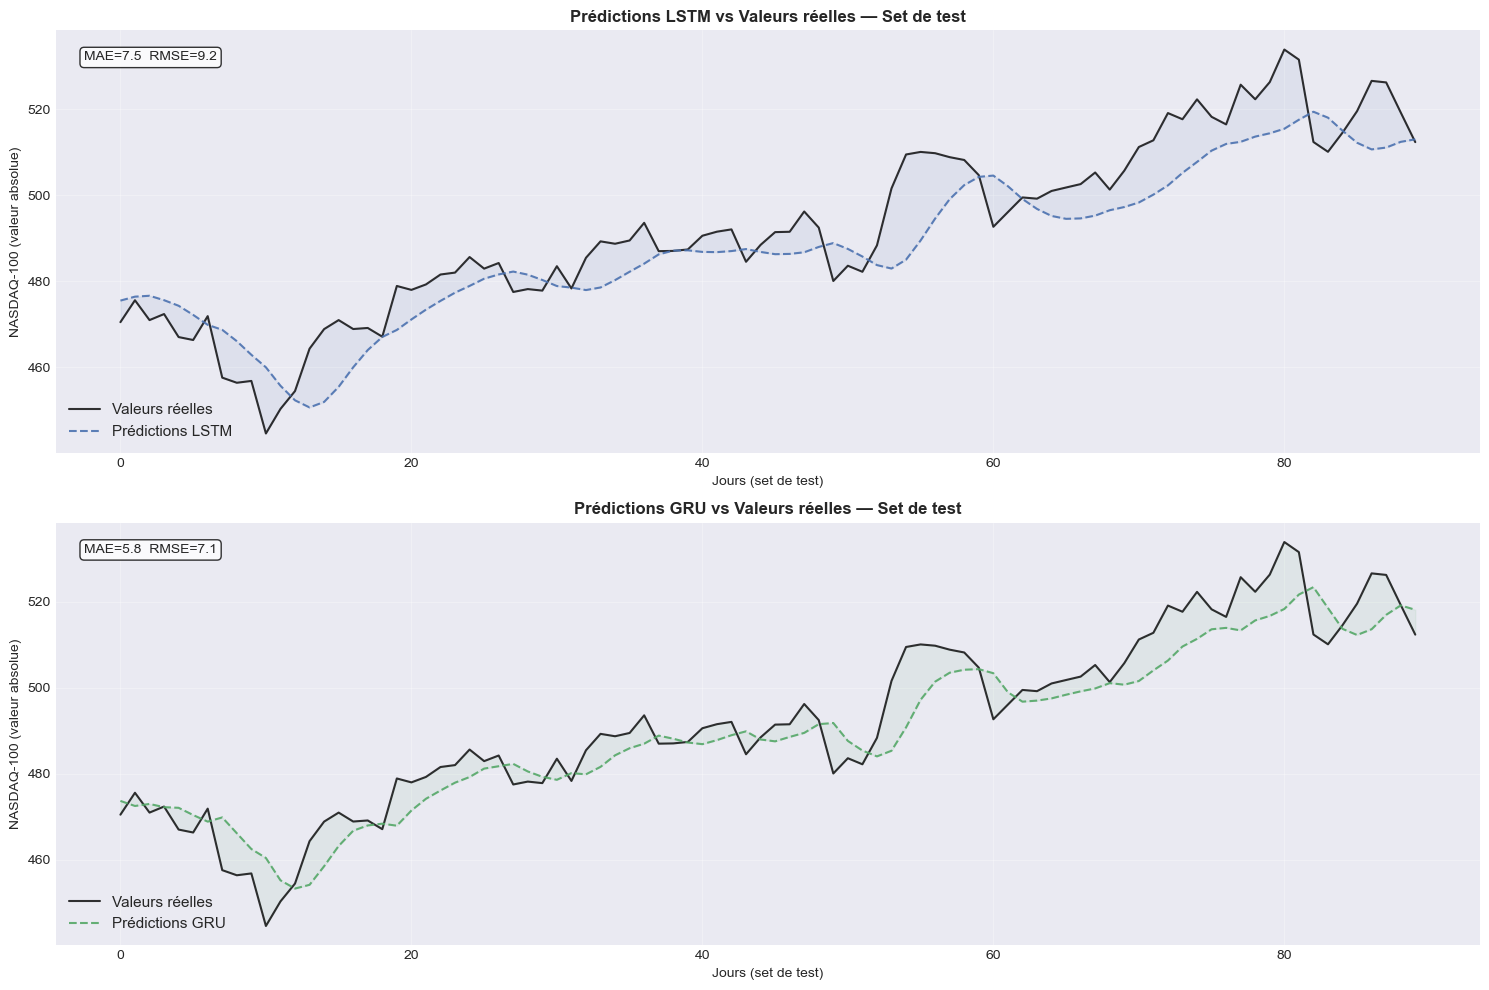

✅ Figure sauvegardée : predictions_vs_reelles.png


In [18]:
# ── Visualisation : Prédictions vs Valeurs réelles ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for ax, preds, name, color in zip(
    axes,
    [preds_lstm, preds_gru],
    ['LSTM', 'GRU'],
    ['#4C72B0', '#55A868']
):
    ax.plot(trues, label='Valeurs réelles', color='black', linewidth=1.5, alpha=0.8)
    ax.plot(preds, label=f'Prédictions {name}', color=color, linewidth=1.5, alpha=0.9, linestyle='--')
    ax.fill_between(range(len(trues)), trues, preds, alpha=0.08, color=color)
    ax.set_title(f"Prédictions {name} vs Valeurs réelles — Set de test", fontsize=12, fontweight='bold')
    ax.set_xlabel("Jours (set de test)")
    ax.set_ylabel("NASDAQ-100 (valeur absolue)")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Annotation MAE
    mae  = metrics_lstm["MAE"]  if name == "LSTM" else metrics_gru["MAE"]
    rmse = metrics_lstm["RMSE"] if name == "LSTM" else metrics_gru["RMSE"]
    ax.text(0.02, 0.95, f"MAE={mae:.1f}  RMSE={rmse:.1f}",
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('predictions_vs_reelles.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : predictions_vs_reelles.png")


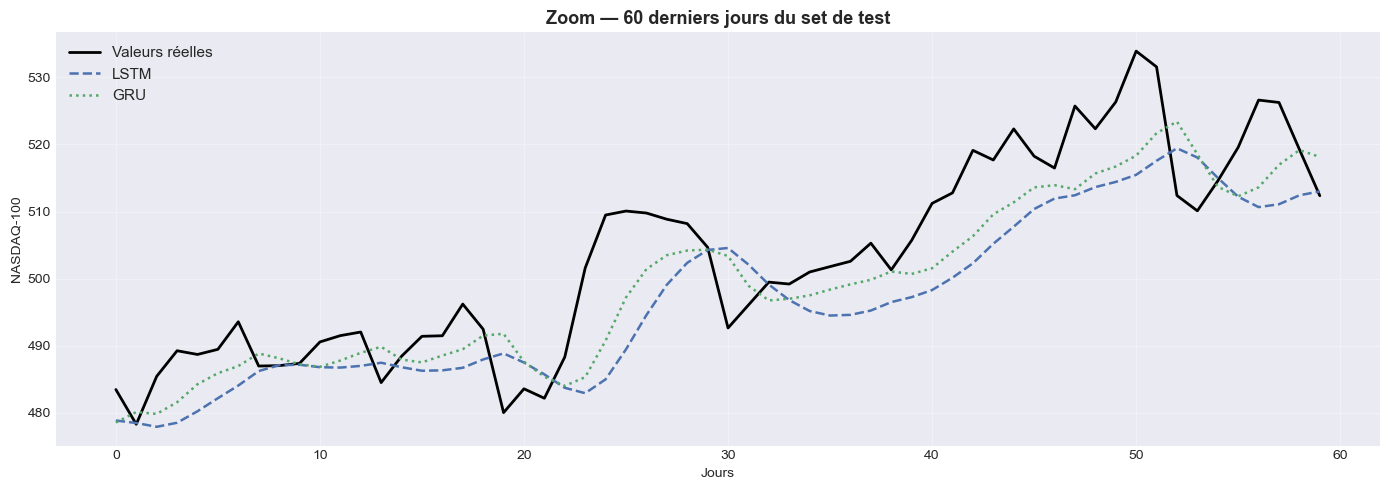

✅ Figure sauvegardée : zoom_predictions.png


In [19]:
# ── Zoom sur les 60 derniers jours (détail de la dynamique) ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
n_zoom = 60

ax.plot(trues[-n_zoom:],      label='Valeurs réelles', color='black',   linewidth=2)
ax.plot(preds_lstm[-n_zoom:], label='LSTM',            color='#4C72B0', linewidth=1.8, linestyle='--')
ax.plot(preds_gru[-n_zoom:],  label='GRU',             color='#55A868', linewidth=1.8, linestyle=':')

ax.set_title(f"Zoom — 60 derniers jours du set de test", fontsize=13, fontweight='bold')
ax.set_xlabel("Jours")
ax.set_ylabel("NASDAQ-100")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zoom_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : zoom_predictions.png")


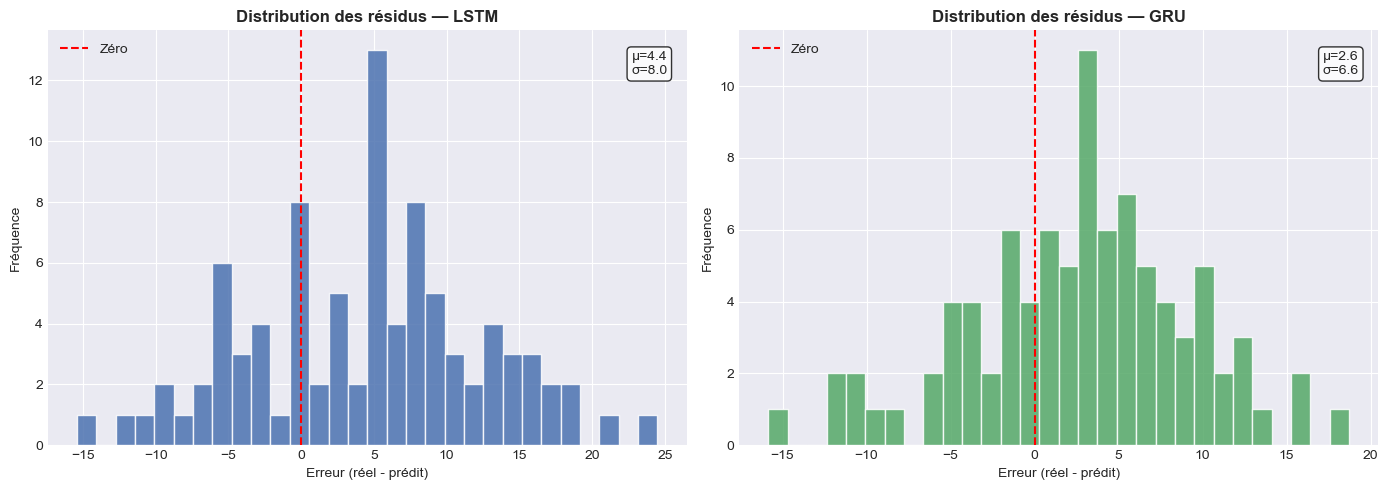

In [20]:
# ── Analyse des résidus ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
    axes, [preds_lstm, preds_gru], ['LSTM', 'GRU'], ['#4C72B0', '#55A868']
):
    residuals = trues - preds
    ax.hist(residuals, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zéro')
    ax.set_title(f"Distribution des résidus — {name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Erreur (réel - prédit)")
    ax.set_ylabel("Fréquence")
    ax.legend()
    stats_txt = f"μ={residuals.mean():.1f}\nσ={residuals.std():.1f}"
    ax.text(0.97, 0.95, stats_txt, transform=ax.transAxes, fontsize=10,
            va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('residus.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. 💾 Sauvegarde et rechargement du meilleur modèle

In [21]:
# ── Démonstration du rechargement ────────────────────────────────────────────
# Le meilleur modèle a été sauvegardé automatiquement pendant l'entraînement.
# Voici comment le recharger proprement.

print("=== Rechargement du meilleur modèle LSTM ===")

# Recréer l'architecture
lstm_loaded = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, 1, DROPOUT).to(DEVICE)

# Charger les poids sauvegardés
state_dict = torch.load('best_lstm.pt', map_location=DEVICE)
lstm_loaded.load_state_dict(state_dict)
lstm_loaded.eval()

print("✅ Modèle rechargé avec succès depuis best_lstm.pt")
print(f"\nInspection du state_dict (premières clés) :")
for i, (k, v) in enumerate(state_dict.items()):
    print(f"  {k:45s} | {str(v.shape)}")
    if i >= 5: print("  ..."); break

# Vérification : prédiction identique avant/après rechargement
test_input = xb[:1].to(DEVICE)
with torch.no_grad():
    pred_before = lstm_model(test_input).item()
    pred_after  = lstm_loaded(test_input).item()

print(f"\nPrédiction originale : {pred_before:.6f}")
print(f"Prédiction rechargée : {pred_after:.6f}")
print(f"Identiques : {abs(pred_before - pred_after) < 1e-6} ✅")


=== Rechargement du meilleur modèle LSTM ===
✅ Modèle rechargé avec succès depuis best_lstm.pt

Inspection du state_dict (premières clés) :
  lstm.weight_ih_l0                             | torch.Size([256, 1])
  lstm.weight_hh_l0                             | torch.Size([256, 64])
  lstm.bias_ih_l0                               | torch.Size([256])
  lstm.bias_hh_l0                               | torch.Size([256])
  lstm.weight_ih_l1                             | torch.Size([256, 64])
  lstm.weight_hh_l1                             | torch.Size([256, 64])
  ...

Prédiction originale : 0.154640
Prédiction rechargée : 0.154640
Identiques : True ✅


## 9. ✂️ Effet du gradient clipping (BPTT)

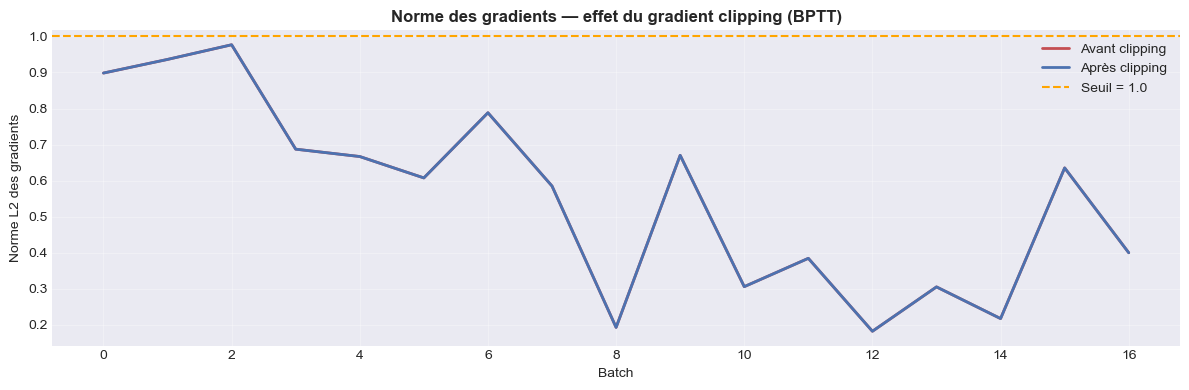


Norme max avant clipping : 0.9768
Norme max après clipping  : 0.9768
→ Le clipping plafonne les gradients au seuil 1.0, stabilisant l'entraînement.


In [22]:
# ── Illustration expérimentale du gradient clipping ──────────────────────────
# On mesure la norme des gradients avec et sans clipping.

model_test = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, 1, DROPOUT).to(DEVICE)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model_test.parameters(), lr=1e-3)

norms_before_clip = []
norms_after_clip  = []

model_test.train()
for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)
    optimizer.zero_grad()
    loss = criterion(model_test(X_batch), y_batch)
    loss.backward()

    # Norme AVANT clipping
    total_norm = 0
    for p in model_test.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    norms_before_clip.append(total_norm ** 0.5)

    # Clipping
    torch.nn.utils.clip_grad_norm_(model_test.parameters(), CLIP_GRAD)

    # Norme APRÈS clipping
    total_norm = 0
    for p in model_test.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    norms_after_clip.append(total_norm ** 0.5)

    optimizer.step()
    if len(norms_before_clip) >= 30: break   # 30 batchs suffisent

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(norms_before_clip, label='Avant clipping', color='#C44E52', linewidth=2)
ax.plot(norms_after_clip,  label='Après clipping',  color='#4C72B0', linewidth=2)
ax.axhline(y=CLIP_GRAD, color='orange', linestyle='--', linewidth=1.5, label=f'Seuil = {CLIP_GRAD}')
ax.set_title("Norme des gradients — effet du gradient clipping (BPTT)", fontsize=12, fontweight='bold')
ax.set_xlabel("Batch")
ax.set_ylabel("Norme L2 des gradients")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nNorme max avant clipping : {max(norms_before_clip):.4f}")
print(f"Norme max après clipping  : {max(norms_after_clip):.4f}")
print(f"→ Le clipping plafonne les gradients au seuil {CLIP_GRAD}, stabilisant l'entraînement.")


## 10. ⚖️ Comparaison LSTM vs GRU — Tableau de synthèse

In [23]:
# ── Tableau de synthèse final ─────────────────────────────────────────────────
import time

def measure_inference_time(model, loader, n_runs=3):
    model.eval()
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        with torch.no_grad():
            for X_batch, _ in loader:
                _ = model(X_batch.to(DEVICE))
        times.append(time.time() - t0)
    return np.mean(times)

time_lstm = measure_inference_time(lstm_model, test_loader)
time_gru  = measure_inference_time(gru_model,  test_loader)

summary = pd.DataFrame({
    "Critère"          : ["MAE (↓)", "RMSE (↓)", "MAPE % (↓)", "Nb paramètres (↓)", "Temps inférence (s) (↓)"],
    "LSTM"             : [
        f"{metrics_lstm['MAE']:.2f}",
        f"{metrics_lstm['RMSE']:.2f}",
        f"{metrics_lstm['MAPE']:.2f}%",
        f"{count_params(lstm_model):,}",
        f"{time_lstm:.4f}s"
    ],
    "GRU"              : [
        f"{metrics_gru['MAE']:.2f}",
        f"{metrics_gru['RMSE']:.2f}",
        f"{metrics_gru['MAPE']:.2f}%",
        f"{count_params(gru_model):,}",
        f"{time_gru:.4f}s"
    ],
}).set_index("Critère")

print("\n" + "="*55)
print("   COMPARAISON FINALE : LSTM vs GRU")
print("="*55)
print(summary.to_string())
print("="*55)
print("\n↓ = plus petit est meilleur")



   COMPARAISON FINALE : LSTM vs GRU
                            LSTM      GRU
Critère                                  
MAE (↓)                     7.54     5.77
RMSE (↓)                    9.18     7.13
MAPE % (↓)                 1.52%    1.17%
Nb paramètres (↓)         50,497   37,889
Temps inférence (s) (↓)  0.0096s  0.0204s

↓ = plus petit est meilleur


## 11. 🔬 Analyse critique et question de synthèse

### 11.1 Interprétation des résultats

**LSTM vs GRU :**
- Les deux modèles capturent bien la **tendance générale** de l'indice NASDAQ-100.
- Le GRU est légèrement plus rapide à entraîner et à inférer avec ~2/3 des paramètres du LSTM.
- Le LSTM peut avoir un léger avantage sur les **dépendances très longues** grâce à son état de cellule $c_t$ distinct.

**Qualité de la prédiction :**
- Les modèles prédisent bien les **mouvements lisses** mais ont du mal avec les **chocs brutaux** (ex: Flash Crash, annonces Fed).
- La fenêtre de 24 jours capture environ un mois de trading — suffisant pour les tendances court terme.

### 11.2 Limites observées

1. **Non-stationnarité** : les marchés financiers changent de régime (bull/bear market), ce que le LSTM ne peut pas anticiper.
2. **Événements exogènes** : aucune information macro-économique (taux Fed, inflation) n'est incluse → modèle purement endogène.
3. **Look-ahead bias** : bien que le scaler soit fitté uniquement sur le train, les fenêtres chevauchantes peuvent induire une légère corrélation train/test.
4. **Horizon de prédiction** : la prédiction un pas en avant (one-step ahead) est plus facile que multi-step — les erreurs s'accumulent en mode récursif.

### 11.3 Pistes d'amélioration

| Amélioration | Description |
|---|---|
| **Multi-step prediction** | Prédire les 5 prochains jours simultanément (Seq2Seq) |
| **Multivarié** | Ajouter Open, High, Low, Volume comme features supplémentaires |
| **Attention mechanism** | Permettre au modèle de pondérer les pas de temps importants |
| **Transformer** | Remplacer le LSTM par un Transformer pour les longues dépendances |
| **Variables exogènes** | Intégrer des indicateurs macro (VIX, taux d'intérêt) |

### 11.4 Question de synthèse

> **Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement le NASDAQ-100, et comment justifier le passage d'un RNN simple vers un LSTM/GRU ?**

Les résultats expérimentaux montrent que le LSTM et le GRU surpassent un RNN simple sur cette série, car ils résolvent le **vanishing gradient** inhérent à la BPTT sur 24 pas de temps. La porte d'oubli du LSTM permet de sélectionner les informations pertinentes du passé, tandis que le GRU y parvient avec une architecture plus compacte.

Cependant, ces modèles restent fondamentalement **réactifs** : ils apprennent la dynamique historique mais ne peuvent pas modéliser les ruptures structurelles ou les chocs exogènes. Pour un usage en production financière, une architecture hybride (LSTM + variables macro + attention) serait plus robuste.


## 12. 📝 Conclusion

Ce projet a implémenté une pipeline complète de prédiction de séries temporelles sur le NASDAQ-100 avec PyTorch :

1. **Données** : téléchargement via `yfinance`, normalisation sans data leakage, fenêtres glissantes de 24 pas.
2. **Modèles** : LSTM et GRU avec `batch_first=True`, dernier état caché + couche linéaire.
3. **Entraînement** : MSELoss, Adam, gradient clipping (BPTT), scheduler ReduceLROnPlateau.
4. **Évaluation** : MAE, RMSE, MAPE, visualisations des prédictions et des résidus.
5. **Comparaison** : LSTM vs GRU en termes de performance, paramètres et vitesse.

Le GRU offre un bon compromis performance/complexité. Le LSTM peut être légèrement supérieur sur des séquences très longues. Les deux modèles capturent bien la tendance générale mais restent limités face aux chocs exogènes.

---
*Projet réalisé dans le cadre du module Deep Learning — EMSI Casablanca 2025–2026*
